# Fleet Model Runner

Run the fleet model from the config file and load the saved result tables.

# Konfigurierte Policy-Szenarien und BEV-Zielpfade

Die Namen und Prozentwerte werden direkt aus `fleet_model_config.json` gelesen. Neue Einträge unter `bev_target_scenarios` erscheinen automatisch in den Modellresultaten und Diagrammen.

In [11]:
import importlib.util
from pathlib import Path
import pandas as pd

model_dir = Path(r"C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model")
script_path = model_dir / "fleet_model_with_policies.py"
config_path = model_dir / "fleet_model_config.json"

spec = importlib.util.spec_from_file_location("fleet_model_with_policies", script_path)
fleet_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fleet_model)
model_config = fleet_model.load_config(config_path)

fixed_scenarios = model_config["policies"]["scenarios"]
bev_target_scenarios = model_config["policies"].get("bev_target_scenarios", {})
all_scenarios = fleet_model.policy_scenario_names(model_config)

scenario_overview = pd.DataFrame({
    "Szenario": all_scenarios,
    "Typ": [
        "BEV-Zielpfad" if name in bev_target_scenarios else "Feste Policy"
        for name in all_scenarios
    ],
})
display(scenario_overview)

start_year = int(model_config["years"]["start_year"])
end_year = int(model_config["years"]["end_year"])
bev_target_overview = pd.DataFrame(
    [
        {
            "Szenario": scenario_name,
            "Jahr": year,
            "BEV-Zielanteil [%]": 100 * fleet_model.bev_target_share(
                year, scenario_name, model_config
            ),
        }
        for scenario_name in bev_target_scenarios
        for year in range(start_year, end_year + 1)
    ]
)

display(
    bev_target_overview.pivot(
        index="Jahr", columns="Szenario", values="BEV-Zielanteil [%]"
    ).round(3)
)

,Szenario,Typ
0,diesel_fahrverbot,Feste Policy
1,abwrackpraemie,Feste Policy
2,verbrenneraus_2035,BEV-Zielpfad
3,verbrenneraus_light,BEV-Zielpfad
4,baseline_ev_growth,BEV-Zielpfad
5,stronger_ev_growth,BEV-Zielpfad


Szenario,baseline_ev_growth,stronger_ev_growth,verbrenneraus_2035,verbrenneraus_light
Jahr,,,,
2025,19.159,19.159,19.159,19.159
2026,21.654,22.277,27.243,26.243
2027,24.148,25.396,35.327,33.327
2028,26.643,28.514,43.412,40.412
2029,29.137,31.632,51.496,47.496
2030,31.632,34.750,59.580,54.580
2031,34.126,37.868,67.664,61.664
2032,36.621,40.986,75.748,68.748
2033,39.115,44.104,83.832,75.832


In [12]:
from pathlib import Path
import subprocess
import sys

model_dir = Path(r"C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model")
script_path = model_dir / "fleet_model_with_policies.py"
config_path = model_dir / "fleet_model_config.json"

command = [sys.executable, str(script_path), "--config", str(config_path)]
print(" ".join(command))
subprocess.run(command, check=True)

c:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\.venv\Scripts\python.exe C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_with_policies.py --config C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_config.json


CompletedProcess(args=['c:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\.venv\\Scripts\\python.exe', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_with_policies.py', '--config', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_config.json'], returncode=0)

In [13]:
import pandas as pd

results_dir = model_dir / "Results"

result_files = {
    path.stem: path
    for path in results_dir.glob("*.csv")
}

results = {
    name: pd.read_csv(path, sep=";")
    for name, path in result_files.items()
}

results.keys()

dict_keys(['emissions_by_phase', 'emissions_summary_by_year_phase', 'emissions_summary_by_year_total', 'emissions_summary_total_by_scenario', 'emission_parameters_long_prepared', 'fleet_size_final_stock_all', 'fleet_size_new_vehicles_all', 'fleet_size_summary_all', 'fleet_size_target_paths_all', 'fleet_total', 'hazard_pooled', 'paper_scenario_summary_table', 'policy_exits_all', 'policy_final_stock_all', 'policy_final_stock_all_prepared_for_emissions', 'policy_missing_vehicles_all', 'policy_new_vehicles_all', 'policy_reentries_all', 'policy_stock_before_new_vehicles_all', 'policy_summary_all', 'prepared_exits_lca', 'prepared_final_stock_lca', 'prepared_new_vehicles_lca', 'reentry_pooled', 'reentry_yearly'])

In [14]:
# Main result dataframes for evaluation
policy_summary_all = results["policy_summary_all"]
policy_final_stock_all = results["policy_final_stock_all"]
policy_exits_all = results["policy_exits_all"]
policy_reentries_all = results["policy_reentries_all"]
policy_new_vehicles_all = results["policy_new_vehicles_all"]

policy_summary_all.head()

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,diesel_fahrverbot,2025,4.912622e+07,4.912620e+07,1.600000e+01,4.912620e+07,-1.600000e+01
1,diesel_fahrverbot,2026,4.882010e+07,4.602304e+07,2.797060e+06,4.882010e+07,-7.450581e-09
2,diesel_fahrverbot,2027,4.851589e+07,4.565813e+07,2.857763e+06,4.851589e+07,7.450581e-09
3,diesel_fahrverbot,2028,4.821358e+07,4.530211e+07,2.911469e+06,4.821358e+07,0.000000e+00
4,diesel_fahrverbot,2029,4.791315e+07,4.495760e+07,2.955549e+06,4.791315e+07,7.450581e-09


In [15]:
policy_summary_all

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,diesel_fahrverbot,2025,4.912622e+07,4.912620e+07,1.600000e+01,4.912620e+07,-1.600000e+01
1,diesel_fahrverbot,2026,4.882010e+07,4.602304e+07,2.797060e+06,4.882010e+07,-7.450581e-09
2,diesel_fahrverbot,2027,4.851589e+07,4.565813e+07,2.857763e+06,4.851589e+07,7.450581e-09
3,diesel_fahrverbot,2028,4.821358e+07,4.530211e+07,2.911469e+06,4.821358e+07,0.000000e+00
4,diesel_fahrverbot,2029,4.791315e+07,4.495760e+07,2.955549e+06,4.791315e+07,7.450581e-09
...,...,...,...,...,...,...,...
157,stronger_ev_growth,2047,4.281450e+07,3.981241e+07,3.002085e+06,4.281450e+07,0.000000e+00
158,stronger_ev_growth,2048,4.254771e+07,3.958003e+07,2.967681e+06,4.254771e+07,-7.450581e-09
159,stronger_ev_growth,2049,4.228259e+07,3.933506e+07,2.947530e+06,4.228259e+07,-7.450581e-09
160,stronger_ev_growth,2050,4.201912e+07,3.910798e+07,2.911131e+06,4.201912e+07,0.000000e+00


# Plot

Gefundene Szenarien:
['abwrackpraemie', 'baseline_ev_growth', 'diesel_fahrverbot', 'stronger_ev_growth', 'verbrenneraus_2035', 'verbrenneraus_light']

Gefundene Antriebsarten:
['Benzin', 'Diesel', 'Elektro (BEV)', 'Hybrid']


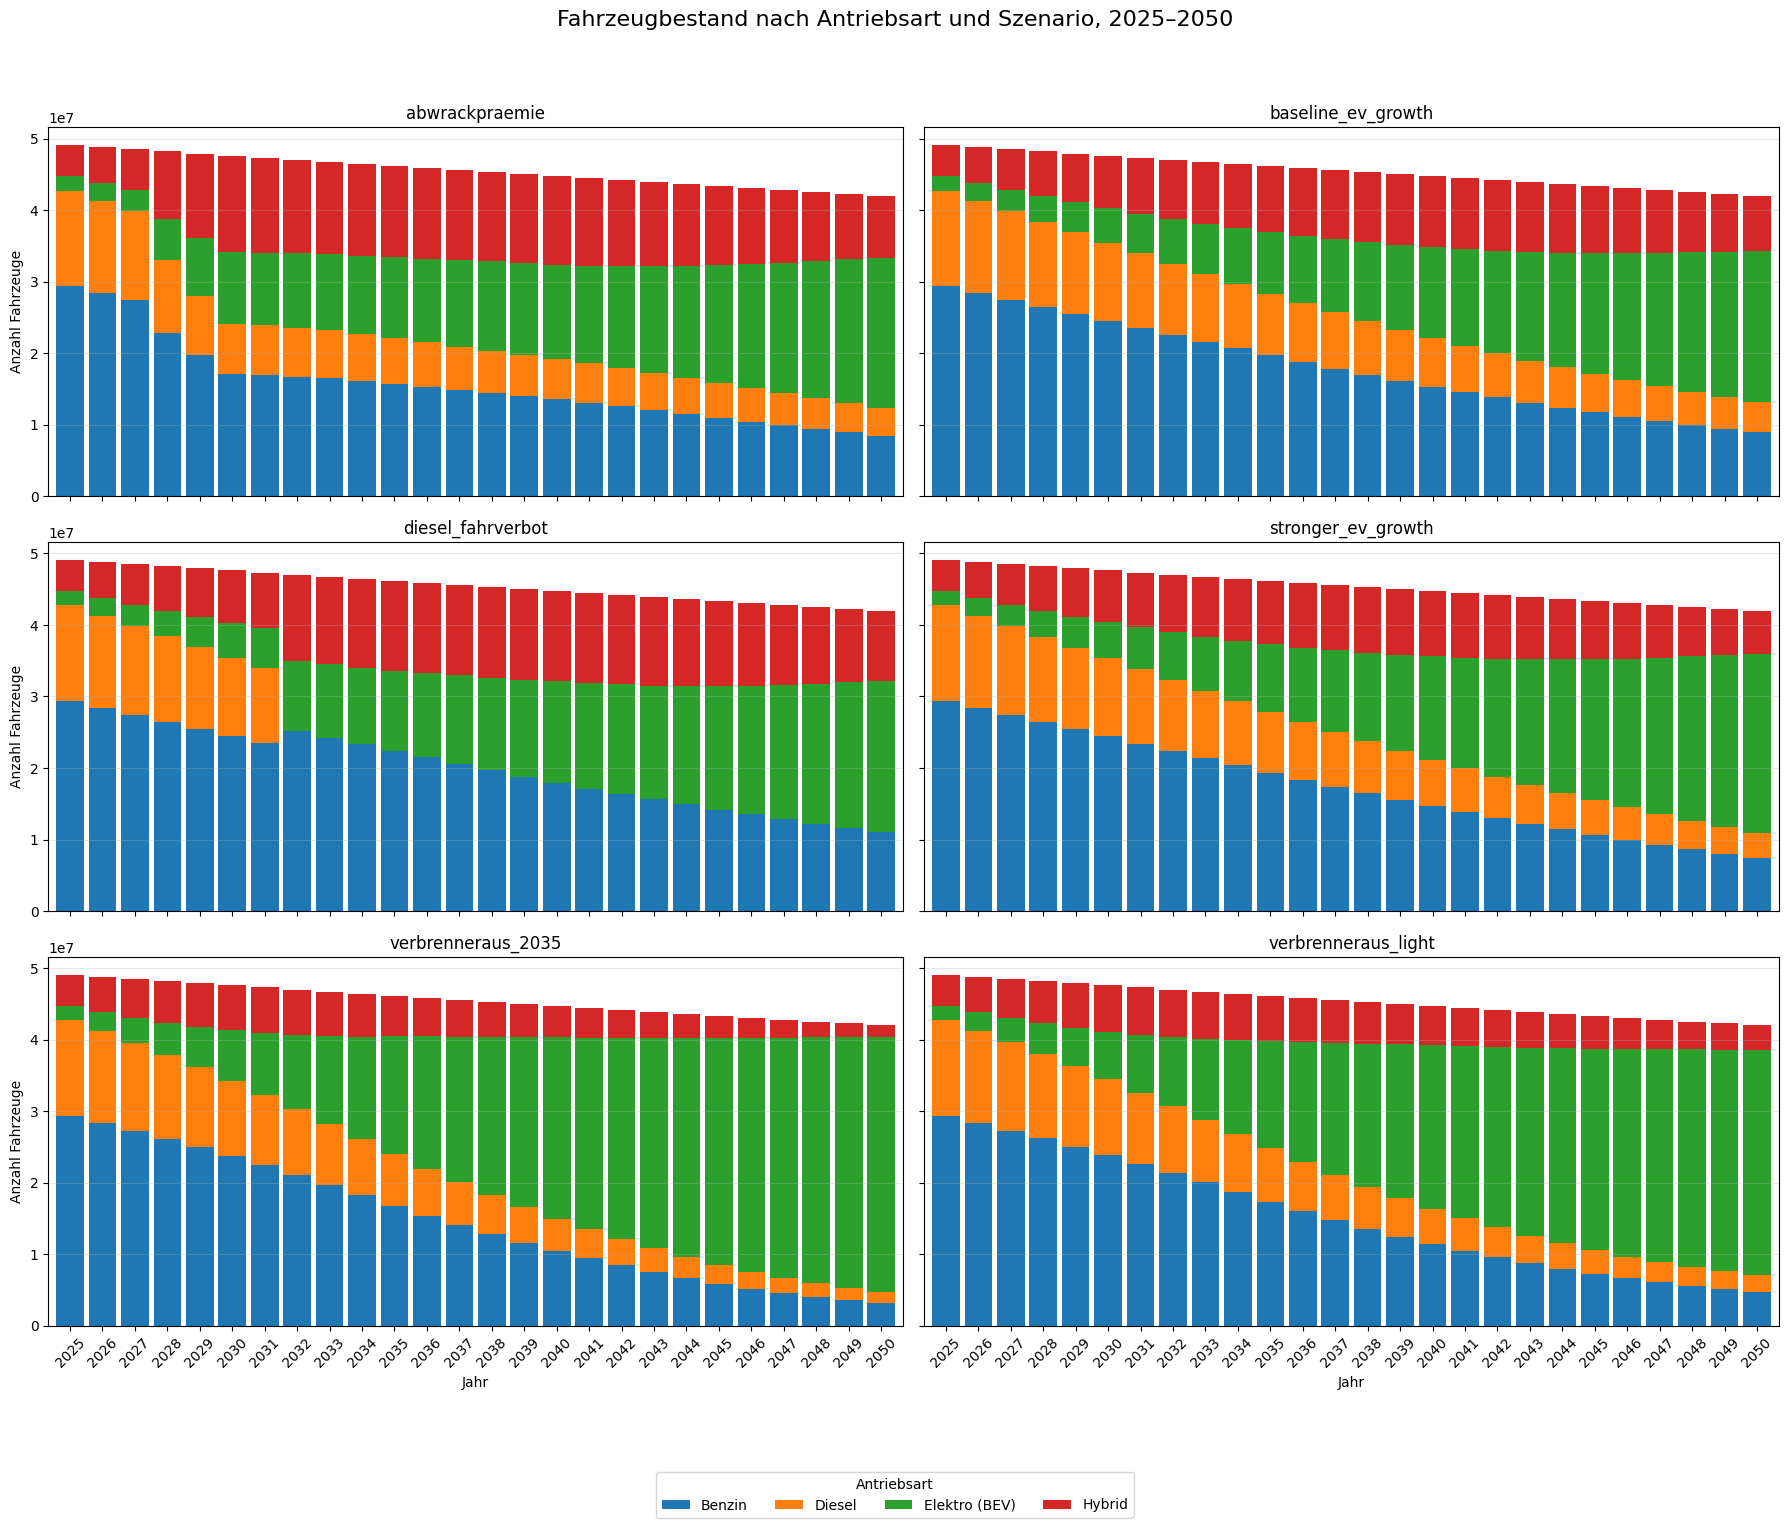

Grafik gespeichert unter:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\Results\policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png


In [16]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

# ------------------------------------------------------------
# 1. Frisch berechnete Ergebnisdaten verwenden
# ------------------------------------------------------------

df = policy_final_stock_all.copy()

# ------------------------------------------------------------
# 2. Datentypen bereinigen
# ------------------------------------------------------------

df["Jahr"] = df["Jahr"].astype(int)
df["finaler_bestand"] = pd.to_numeric(df["finaler_bestand"], errors="coerce")

# ------------------------------------------------------------
# 3. Nur Jahre 2025 bis 2050 verwenden
# ------------------------------------------------------------

df = df[(df["Jahr"] >= 2025) & (df["Jahr"] <= 2050)]

# ------------------------------------------------------------
# 4. Fahrzeugbestand pro Szenario, Jahr und Antriebsart summieren
# ------------------------------------------------------------

agg = (
    df.groupby(["Szenario", "Jahr", "Antriebsart"], as_index=False)["finaler_bestand"]
    .sum()
)

# ------------------------------------------------------------
# 5. Szenarien und Antriebsarten bestimmen
# ------------------------------------------------------------

szenarien = sorted(agg["Szenario"].unique())
antriebsarten = sorted(agg["Antriebsart"].unique())

print("Gefundene Szenarien:")
print(szenarien)

print("\nGefundene Antriebsarten:")
print(antriebsarten)

# ------------------------------------------------------------
# 6. Dynamisches Plot-Raster für alle Szenarien erstellen
# ------------------------------------------------------------

ncols = 2
nrows = math.ceil(len(szenarien) / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 5 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False
)

axes = axes.flatten()

for ax, szenario in zip(axes, szenarien):
    
    data_szenario = agg[agg["Szenario"] == szenario]

    # Pivot-Tabelle:
    # Zeilen = Jahre
    # Spalten = Antriebsarten
    # Werte = Fahrzeugbestand
    pivot = (
        data_szenario
        .pivot_table(
            index="Jahr",
            columns="Antriebsart",
            values="finaler_bestand",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(range(2025, 2051), fill_value=0)
    )

    # Sicherstellen, dass in jedem Subplot alle Antriebsarten vorkommen
    pivot = pivot.reindex(columns=antriebsarten, fill_value=0)

    # Gestapeltes Balkendiagramm
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(szenario)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Anzahl Fahrzeuge")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

    # Einzelne Legende entfernen, da später gemeinsame Legende kommt
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Nicht benötigte Subplots ausblenden
for i in range(len(szenarien), len(axes)):
    axes[i].set_visible(False)

# ------------------------------------------------------------
# 7. Gemeinsame Legende erstellen
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Antriebsart",
    loc="lower center",
    ncol=len(antriebsarten),
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "Fahrzeugbestand nach Antriebsart und Szenario, 2025–2050",
    fontsize=16
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# ------------------------------------------------------------
# 8. Grafik speichern
# ------------------------------------------------------------

output_path = results_dir / "policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Grafik gespeichert unter:\n{output_path}")

# Emissionen je Szenario als DataFrames

Jeder DataFrame zeigt die jährlichen Emissionen nach Lebenszyklusphase, die Jahressumme und am Ende die Summe über den gesamten Modellzeitraum. Alle Werte sind in t CO₂e angegeben.

In [17]:
# Ein DataFrame pro Szenario: Einzelteile, Jahressumme und Gesamtsumme
emissionen_phasen = results["emissions_summary_by_year_phase"].copy()
emissionen_total = results["emissions_summary_by_year_total"].copy()

phase_names = {
    "production": "Fahrzeugproduktion [t CO2e]",
    "battery_production": "Batterieproduktion [t CO2e]",
    "use": "Nutzungsphase [t CO2e]",
    "end_of_life": "End-of-Life [t CO2e]",
}
phase_columns = list(phase_names.values())

emissionen_nach_szenario = {}

for szenario in sorted(emissionen_phasen["Szenario"].unique()):
    einzelteile = (
        emissionen_phasen.loc[emissionen_phasen["Szenario"] == szenario]
        .pivot_table(
            index="emission_year",
            columns="phase",
            values="emissions_tco2e",
            aggfunc="sum",
            fill_value=0,
        )
        .rename(columns=phase_names)
        .reindex(columns=phase_columns, fill_value=0)
    )

    jahressummen = (
        emissionen_total.loc[
            emissionen_total["Szenario"] == szenario,
            ["emission_year", "total_emissions_tco2e"],
        ]
        .set_index("emission_year")
        .rename(columns={"total_emissions_tco2e": "Emissionen gesamt [t CO2e]"})
    )

    df_szenario = einzelteile.join(jahressummen, how="outer").sort_index()
    df_szenario.index.name = "Jahr"
    df_szenario.loc["Gesamt 2025–2050"] = df_szenario.sum(numeric_only=True)
    emissionen_nach_szenario[szenario] = df_szenario

# Zugriff z. B.: emissionen_nach_szenario["baseline_ev_growth"]
for szenario, df_szenario in emissionen_nach_szenario.items():
    print(f"\n{szenario}")
    display(df_szenario.style.format("{:,.0f}"))


abwrackpraemie


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,251,658","14,497,941","131,168,233","10,638,448","179,556,280"
2026,"23,865,993","15,231,619","130,739,316","11,132,402","180,969,331"
2027,"85,734,056","55,982,627","130,057,058","10,477,304","282,251,045"
2028,"69,412,847","46,355,323","124,950,539","10,835,758","251,554,467"
2029,"61,522,133","42,003,395","120,212,207","40,853,241","264,590,976"
2030,"24,441,049","17,053,206","115,510,444","36,782,118","193,786,817"
2031,"24,487,244","17,454,418","114,951,850","34,100,716","190,994,227"
2032,"24,654,957","17,947,371","114,213,631","13,022,480","169,838,439"
2033,"23,121,496","17,183,081","113,340,942","13,149,920","166,795,440"



baseline_ev_growth


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,251,658","14,497,941","131,168,233","10,638,448","179,556,280"
2026,"23,865,993","15,231,619","130,739,316","11,132,402","180,969,331"
2027,"24,425,255","15,949,204","130,057,058","10,477,304","180,908,822"
2028,"24,911,811","16,636,618","129,103,186","10,835,758","181,487,373"
2029,"25,624,929","17,495,070","127,857,184","11,196,433","182,173,616"
2030,"26,007,819","18,146,386","126,311,718","11,529,028","181,994,951"
2031,"26,325,646","18,764,824","124,832,269","11,917,455","181,840,193"
2032,"26,674,732","19,417,650","123,197,833","12,237,945","181,528,160"
2033,"27,051,870","20,103,996","121,455,329","12,535,870","181,147,065"



diesel_fahrverbot


...

,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,237,048","14,574,017","131,168,233","10,638,448","179,617,747"
2026,"23,838,642","15,389,939","130,692,075","11,132,402","181,053,059"
2027,"24,387,141","16,195,582","129,911,902","10,477,304","180,971,929"
2028,"24,865,049","16,976,272","128,806,306","10,837,540","181,485,168"
2029,"25,570,788","17,937,600","127,352,015","11,201,757","182,062,160"
2030,"25,949,378","18,692,877","125,535,999","11,539,622","181,717,876"
2031,"26,262,829","19,417,467","123,746,156","11,935,005","181,361,457"
2032,"26,606,839","20,180,385","121,749,814","12,264,206","180,801,245"
2033,"26,977,995","20,980,889","119,591,375","12,573,326","180,123,585"



verbrenneraus_2035


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,120,711","15,179,821","131,168,233","10,638,448","180,107,213"
2026,"23,620,602","16,651,927","130,315,886","11,132,402","181,720,818"
2027,"24,082,572","18,163,306","128,755,189","10,477,304","181,478,372"
2028,"24,489,959","19,696,571","126,437,632","10,851,737","181,475,899"
2029,"25,134,247","21,494,329","123,314,417","11,244,183","181,187,176"
2030,"25,474,653","23,104,497","119,322,081","11,624,143","179,525,375"
2031,"25,748,804","24,709,366","115,021,688","12,075,276","177,555,135"
2032,"26,047,602","26,391,908","110,083,042","12,474,558","174,997,111"
2033,"26,366,148","28,152,311","104,526,408","12,874,107","171,918,974"



verbrenneraus_light


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,144,138","15,057,830","131,168,233","10,638,448","180,008,649"
2026,"23,664,544","16,397,618","130,391,639","11,132,402","181,586,204"
2027,"24,144,055","17,766,236","128,988,234","10,477,304","181,375,830"
2028,"24,565,879","19,146,550","126,915,270","10,848,878","181,476,578"
2029,"25,222,930","20,773,406","124,129,600","11,235,635","181,361,571"
2030,"25,571,592","22,207,535","120,578,650","11,607,100","179,964,876"
2031,"25,854,303","23,630,087","116,789,386","12,046,956","178,320,732"
2032,"26,162,905","25,121,207","112,451,930","12,432,023","176,168,064"
2033,"26,492,781","26,680,886","107,592,020","12,813,177","173,578,864"


# Anteil der Produktion an den Gesamtemissionen

Ausgabe je Szenario und Jahr, jeweils ohne und mit Batterieproduktion. Anschließend werden der Durchschnitt über alle Szenarien sowie stärkste und schwächste Veränderungen zusammengefasst.

In [18]:
# Produktionsanteile an den jährlichen Gesamtemissionen je Szenario
emissionen_phase_wide = (
    emissionen_phasen.pivot_table(
        index=["Szenario", "emission_year"],
        columns="phase",
        values="emissions_tco2e",
        aggfunc="sum",
        fill_value=0,
    ).reset_index()
)

produktionsanteile = emissionen_phase_wide.merge(
    emissionen_total[["Szenario", "emission_year", "total_emissions_tco2e"]],
    on=["Szenario", "emission_year"],
    how="left",
)
produktionsanteile["Produktion ohne Batterie [%]"] = (
    100 * produktionsanteile["production"] / produktionsanteile["total_emissions_tco2e"]
)
produktionsanteile["Produktion inklusive Batterie [%]"] = (
    100 * (produktionsanteile["production"] + produktionsanteile["battery_production"])
    / produktionsanteile["total_emissions_tco2e"]
)

anteil_spalten = [
    "Produktion ohne Batterie [%]",
    "Produktion inklusive Batterie [%]",
]
produktionsanteile_nach_szenario = {
    szenario: gruppe.set_index("emission_year")[anteil_spalten]
        .rename_axis("Jahr").sort_index()
    for szenario, gruppe in produktionsanteile.groupby("Szenario")
}

for szenario, df_anteile in produktionsanteile_nach_szenario.items():
    print(f"\n{szenario}")
    display(df_anteile.style.format("{:.2f} %"))


abwrackpraemie


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,12.95 %,21.02 %
2026,13.19 %,21.60 %
2027,30.38 %,50.21 %
2028,27.59 %,46.02 %
2029,23.25 %,39.13 %
2030,12.61 %,21.41 %
2031,12.82 %,21.96 %
2032,14.52 %,25.08 %
2033,13.86 %,24.16 %



baseline_ev_growth


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,12.95 %,21.02 %
2026,13.19 %,21.60 %
2027,13.50 %,22.32 %
2028,13.73 %,22.89 %
2029,14.07 %,23.67 %
2030,14.29 %,24.26 %
2031,14.48 %,24.80 %
2032,14.69 %,25.39 %
2033,14.93 %,26.03 %



diesel_fahrverbot


...

,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,12.94 %,21.05 %
2026,13.17 %,21.67 %
2027,13.48 %,22.42 %
2028,13.70 %,23.05 %
2029,14.05 %,23.90 %
2030,14.28 %,24.57 %
2031,14.48 %,25.19 %
2032,14.72 %,25.88 %
2033,14.98 %,26.63 %



verbrenneraus_2035


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,12.84 %,21.27 %
2026,13.00 %,22.16 %
2027,13.27 %,23.28 %
2028,13.49 %,24.35 %
2029,13.87 %,25.74 %
2030,14.19 %,27.06 %
2031,14.50 %,28.42 %
2032,14.88 %,29.97 %
2033,15.34 %,31.71 %



verbrenneraus_light


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,12.86 %,21.22 %
2026,13.03 %,22.06 %
2027,13.31 %,23.11 %
2028,13.54 %,24.09 %
2029,13.91 %,25.36 %
2030,14.21 %,26.55 %
2031,14.50 %,27.75 %
2032,14.85 %,29.11 %
2033,15.26 %,30.63 %


In [19]:
# Kompakte Kennzahlen für den Ergebnisteil
erstes_jahr = int(produktionsanteile["emission_year"].min())
letztes_jahr = int(produktionsanteile["emission_year"].max())

anteile_start_ende = produktionsanteile.loc[
    produktionsanteile["emission_year"].isin([erstes_jahr, letztes_jahr]),
    ["Szenario", "emission_year", *anteil_spalten],
].pivot(index="Szenario", columns="emission_year", values=anteil_spalten)
anteile_start_ende.columns = [
    f"{kennzahl} ({jahr})" for kennzahl, jahr in anteile_start_ende.columns
]

for kennzahl in anteil_spalten:
    anteile_start_ende[f"Veränderung {kennzahl} [Prozentpunkte]"] = (
        anteile_start_ende[f"{kennzahl} ({letztes_jahr})"]
        - anteile_start_ende[f"{kennzahl} ({erstes_jahr})"]
    )

durchschnitt_nach_jahr = produktionsanteile.groupby("emission_year")[anteil_spalten].mean()
durchschnitt_nach_jahr.index.name = "Jahr"

display(anteile_start_ende.style.format("{:.2f}"))
display(durchschnitt_nach_jahr.style.format("{:.2f} %"))

for kennzahl in anteil_spalten:
    start_mittel = durchschnitt_nach_jahr.loc[erstes_jahr, kennzahl]
    ende_mittel = durchschnitt_nach_jahr.loc[letztes_jahr, kennzahl]
    delta_spalte = f"Veränderung {kennzahl} [Prozentpunkte]"
    staerkstes_szenario = anteile_start_ende[delta_spalte].idxmax()
    schwaechstes_szenario = anteile_start_ende[delta_spalte].idxmin()
    print(f"\n{kennzahl}")
    print(
        f"Durchschnitt: {start_mittel:.2f} % ({erstes_jahr}) -> "
        f"{ende_mittel:.2f} % ({letztes_jahr}); "
        f"Änderung {ende_mittel - start_mittel:+.2f} Prozentpunkte."
    )
    print(
        f"Stärkster Anstieg: {staerkstes_szenario} "
        f"({anteile_start_ende.loc[staerkstes_szenario, delta_spalte]:+.2f} Prozentpunkte)."
    )
    print(
        f"Schwächste Veränderung: {schwaechstes_szenario} "
        f"({anteile_start_ende.loc[schwaechstes_szenario, delta_spalte]:+.2f} Prozentpunkte)."
    )

,Produktion ohne Batterie [%] (2025),Produktion ohne Batterie [%] (2050),Produktion inklusive Batterie [%] (2025),Produktion inklusive Batterie [%] (2050),Veränderung Produktion ohne Batterie [%] [Prozentpunkte],Veränderung Produktion inklusive Batterie [%] [Prozentpunkte]
Szenario,,,,,,
abwrackpraemie,12.95,18.35,21.02,36.65,5.40,15.63
baseline_ev_growth,12.95,18.26,21.02,36.48,5.31,15.46
diesel_fahrverbot,12.95,17.81,21.02,36.02,4.86,14.99
stronger_ev_growth,12.94,19.89,21.05,41.83,6.95,20.78
verbrenneraus_2035,12.84,27.05,21.27,57.43,14.21,36.17
verbrenneraus_light,12.86,24.05,21.22,49.42,11.19,28.20


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,12.91 %,21.10 %
2026,13.13 %,21.78 %
2027,16.24 %,27.28 %
2028,15.96 %,27.22 %
2029,15.53 %,26.91 %
2030,13.98 %,24.69 %
2031,16.96 %,30.59 %
2032,14.80 %,27.11 %
2033,14.74 %,27.45 %



Produktion ohne Batterie [%]
Durchschnitt: 12.91 % (2025) -> 20.90 % (2050); Änderung +7.99 Prozentpunkte.
Stärkster Anstieg: verbrenneraus_2035 (+14.21 Prozentpunkte).
Schwächste Veränderung: diesel_fahrverbot (+4.86 Prozentpunkte).

Produktion inklusive Batterie [%]
Durchschnitt: 21.10 % (2025) -> 42.97 % (2050); Änderung +21.87 Prozentpunkte.
Stärkster Anstieg: verbrenneraus_2035 (+36.17 Prozentpunkte).
Schwächste Veränderung: diesel_fahrverbot (+14.99 Prozentpunkte).


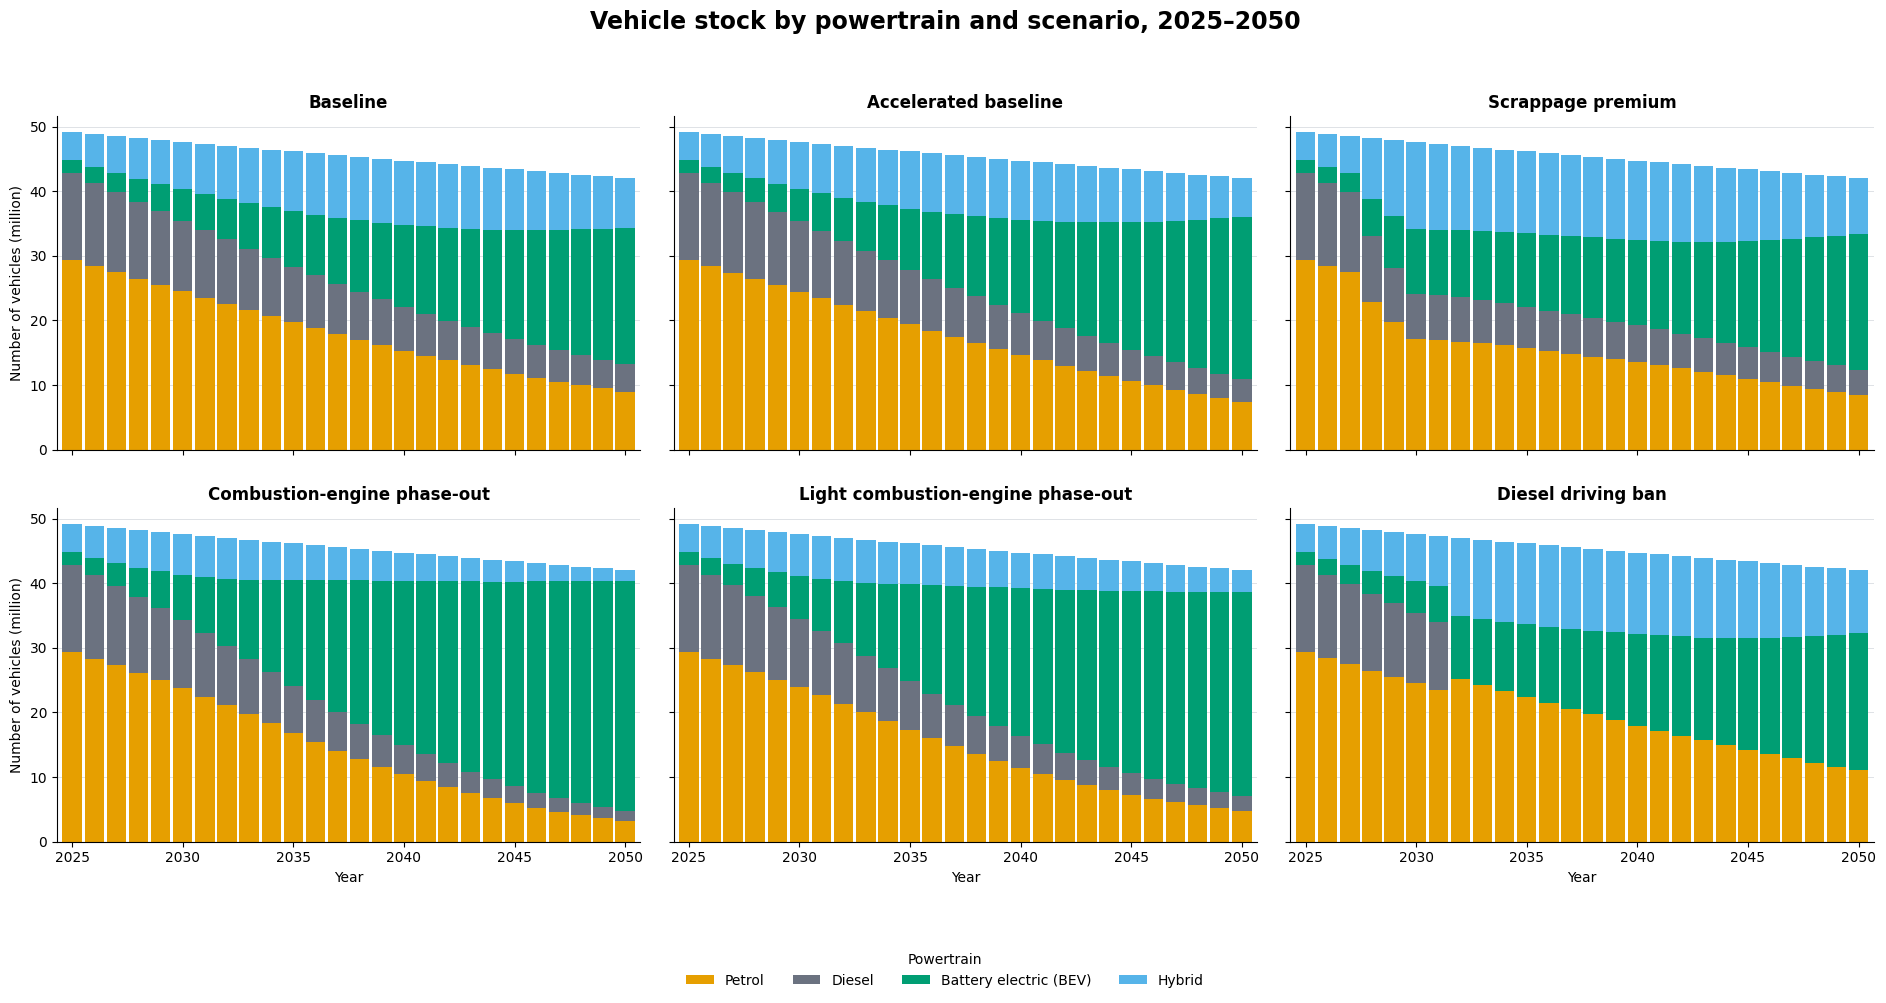

Figure saved to:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\Results\vehicle_stock_by_powertrain_and_scenario_2025_2050.png


In [20]:
# Vehicle stock by powertrain and scenario (English, publication layout)
import math
import pandas as pd
import matplotlib.pyplot as plt

plot_df = policy_final_stock_all.copy()
plot_df["Jahr"] = pd.to_numeric(plot_df["Jahr"], errors="coerce")
plot_df["finaler_bestand"] = pd.to_numeric(plot_df["finaler_bestand"], errors="coerce")
plot_df = plot_df[plot_df["Jahr"].between(2025, 2050)].dropna(subset=["Jahr", "finaler_bestand"])
plot_df["Jahr"] = plot_df["Jahr"].astype(int)

scenario_order = [
    "baseline_ev_growth",
    "stronger_ev_growth",
    "abwrackpraemie",
    "verbrenneraus_2035",
    "verbrenneraus_light",
    "diesel_fahrverbot",
]
scenario_labels = {
    "baseline_ev_growth": "Baseline",
    "stronger_ev_growth": "Accelerated baseline",
    "abwrackpraemie": "Scrappage premium",
    "verbrenneraus_2035": "Combustion-engine phase-out",
    "verbrenneraus_light": "Light combustion-engine phase-out",
    "diesel_fahrverbot": "Diesel driving ban",
}
powertrain_labels = {
    "Benzin": "Petrol",
    "Diesel": "Diesel",
    "Elektro (BEV)": "Battery electric (BEV)",
    "Hybrid": "Hybrid",
    "Sonstige": "Other",
    "Flüssiggas (LPG) (einschl. bivalent)": "Liquefied petroleum gas (LPG)",
    "Erdgas (CNG) (einschl. bivalent)": "Compressed natural gas (CNG)",
}
powertrain_colors = {
    "Benzin": "#E69F00",
    "Diesel": "#6B7280",
    "Elektro (BEV)": "#009E73",
    "Hybrid": "#56B4E9",
    "Sonstige": "#CC79A7",
    "Flüssiggas (LPG) (einschl. bivalent)": "#D55E00",
    "Erdgas (CNG) (einschl. bivalent)": "#0072B2",
}

agg_plot = (
    plot_df.groupby(["Szenario", "Jahr", "Antriebsart"], as_index=False)["finaler_bestand"]
    .sum()
)
powertrains = list(dict.fromkeys(
    [name for name in powertrain_labels if name in agg_plot["Antriebsart"].unique()]
    + sorted(set(agg_plot["Antriebsart"].unique()) - set(powertrain_labels))
))
fallback_colors = plt.get_cmap("tab20").colors
colors = [powertrain_colors.get(name, fallback_colors[i % len(fallback_colors)]) for i, name in enumerate(powertrains)]

fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharex=True, sharey=True, squeeze=False)
years = range(2025, 2051)

for ax, scenario in zip(axes.flat, scenario_order):
    pivot = (
        agg_plot.loc[agg_plot["Szenario"] == scenario]
        .pivot_table(index="Jahr", columns="Antriebsart", values="finaler_bestand", aggfunc="sum", fill_value=0)
        .reindex(index=years, columns=powertrains, fill_value=0)
    )
    pivot.plot(kind="bar", stacked=True, ax=ax, width=0.88, color=colors, edgecolor="none")
    ax.set_title(scenario_labels[scenario], fontsize=12, fontweight="semibold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of vehicles (million)")
    ax.yaxis.set_major_locator(MultipleLocator(10_000_000))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}"))
    tick_positions = list(range(0, len(pivot.index), 5))
    if len(pivot.index) - 1 not in tick_positions:
        tick_positions.append(len(pivot.index) - 1)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([pivot.index[i] for i in tick_positions], rotation=0)
    ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

handles, _ = axes.flat[0].get_legend_handles_labels()
legend_labels = [powertrain_labels.get(name, name) for name in powertrains]
fig.legend(handles, legend_labels, title="Powertrain", loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Vehicle stock by powertrain and scenario, 2025–2050", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0.09, 1, 0.95], h_pad=2.0, w_pad=1.5)

output_path = results_dir / "vehicle_stock_by_powertrain_and_scenario_2025_2050.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")